# Inspect Pools
Generate embeddings with Node2Vec

In [5]:
import json
from pathlib import Path

import numpy as np

import polars as pl
import web3
from eth_hash.auto import keccak

In [37]:
USDC_ADDRESS = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48".lower()

In [6]:
# Create usp3 pool address to tokens mapping from pools.json
with Path("data/pools.json").open() as f:
    pools = json.load(f)["data"]

print(f"Unique protocols: { {p['protocol'] for p in pools} }")

# Create a mapping from pool address to token information
NUM_TOKENS = 2  # Uniswap V3 pools have exactly 2 tokens
pool_to_tokens: dict[str, dict[str, str]] = {}
for pool in pools:
    if pool["protocol"] == "usp3":
        assert len(pool["tokens"]) == NUM_TOKENS
        pool_addr = pool["address"].lower()
        assert pool["tokens"][0]["address"] < pool["tokens"][1]["address"], (
            f"Pool {pool_addr} tokens not in expected order"
            f" {pool['tokens'][0]['address']} >= {pool['tokens'][1]['address']}"
        )
        pool_to_tokens[pool_addr] = {
            "token0_address": pool["tokens"][0]["address"].lower(),
            "token0_symbol": pool["tokens"][0]["symbol"],
            "token1_address": pool["tokens"][1]["address"].lower(),
            "token1_symbol": pool["tokens"][1]["symbol"],
        }
print(f"Loaded {len(pool_to_tokens)} uniswap v3 pools from pools.json")


Unique protocols: {'mpho', 'hsp3', 'blc2', 'sush', 'curv', 'aerb', 'qsp3', 'cml3', 'pks3', 'crm', 'cmpd', 'rayc', 'meta', 'blcr', 'aav2', 'aav3', 'orca', 'tjv1', 'crv2', 'aerc', 'aav1', 'usp2', 'tj21', 'metd', 'usp3', 'raya', 'aave/v3', 'qsp2', 'mkr', 'pksp', 'tjv2'}
Loaded 8149 uniswap v3 pools from pools.json


In [7]:
import networkx as nx
from node2vec import Node2Vec

# Create undirected graph from pool edges
G = nx.Graph()

# Add edges between token pairs (pools represent connections between tokens)
for pool_addr, tokens in pool_to_tokens.items():
    token0 = tokens["token0_address"]
    token1 = tokens["token1_address"]
    # Add edge with pool address as edge attribute for reference
    G.add_edge(token0, token1, pool=pool_addr)

print(f"Graph nodes (unique tokens): {G.number_of_nodes()}")
print(f"Graph edges (pools): {G.number_of_edges()}")
print(f"Is connected: {nx.is_connected(G)}")
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"Number of connected components: {len(components)}")
    print(f"Largest component size: {len(max(components, key=len))}")

Graph nodes (unique tokens): 2250
Graph edges (pools): 5133
Is connected: False
Number of connected components: 4
Largest component size: 2231


In [8]:
# Generate Node2Vec embeddings
# Parameters:
# - dimensions: embedding dimension (64 as requested)
# - walk_length: length of random walk (default 80, reasonable for token connectivity)
# - num_walks: number of walks per node (default 10)
# - workers: parallel workers (4 for efficiency)
# - p: return parameter (1.0 = balanced BFS/DFS)
# - q: in-out parameter (1.0 = balanced local/global structure)

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=80,
    num_walks=10,
    workers=4,
    p=1.0,
    q=1.0,
)

print("Training Node2Vec model...")
model = node2vec.fit(window=10, min_count=1, batch_words=4)

print(f"Embeddings generated for {len(model.wv)} tokens")
print(f"Embedding dimension: {model.wv.vector_size}")

Computing transition probabilities:   0%|          | 0/2250 [00:00<?, ?it/s]

Generating walks (CPU: 2): 100%|██████████| 3/3 [00:06<00:00,  2.33s/it]


Training Node2Vec model...
Embeddings generated for 2250 tokens
Embedding dimension: 64


In [9]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Extract embeddings as numpy array
tokens = list(model.wv.index_to_key)
embeddings = np.array([model.wv[token] for token in tokens])

# Apply UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

print(
    f"UMAP reduced {embeddings.shape[0]} embeddings from {embeddings.shape[1]}D to 2D"
)

/Users/rcurrie/cbot/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced 2250 embeddings from 64D to 2D


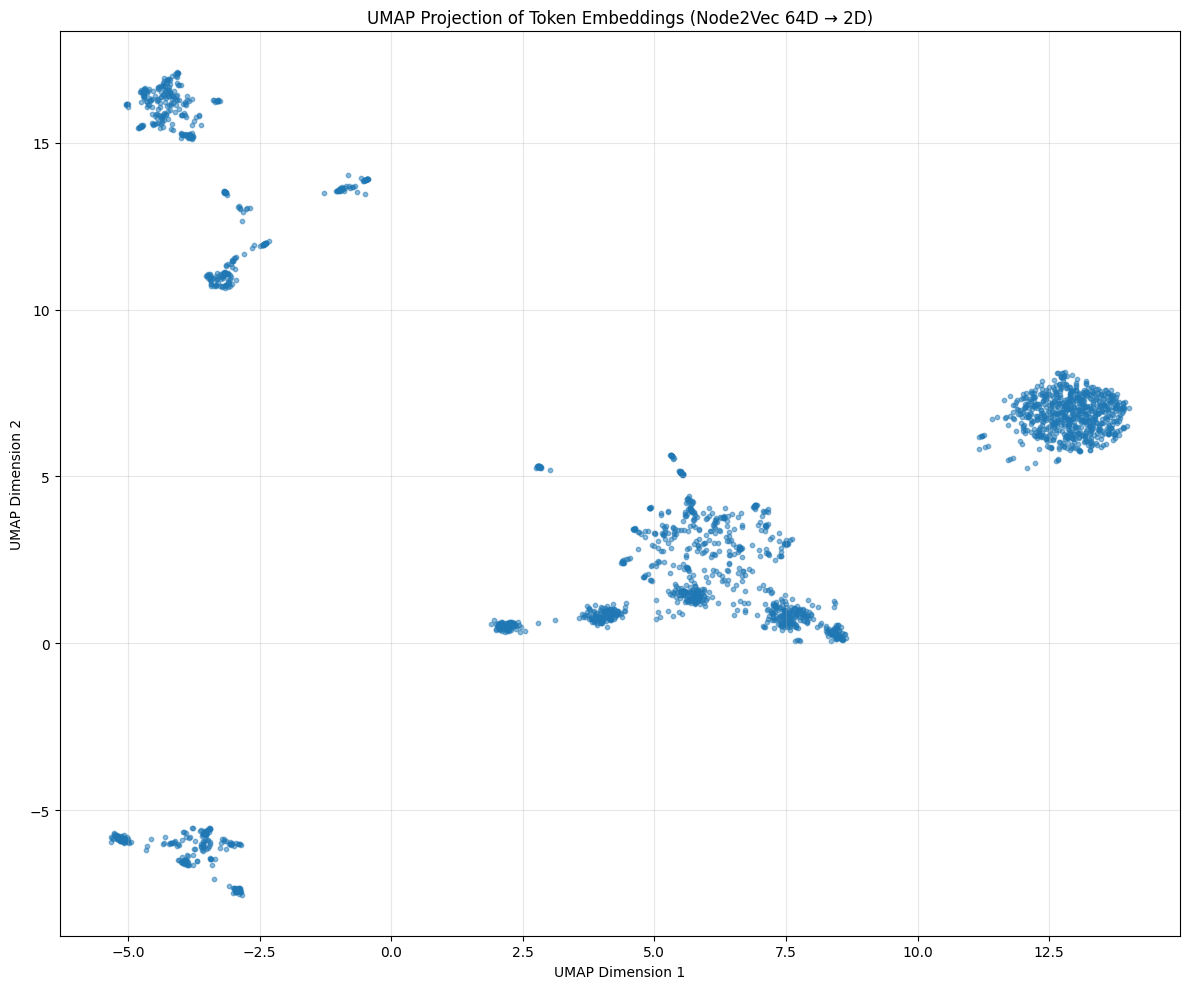

In [10]:
# Plot UMAP projection
plt.figure(figsize=(12, 10))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.5, s=10)
plt.title("UMAP Projection of Token Embeddings (Node2Vec 64D → 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average node degree: {len(G.edges) / len(G.nodes):.2f}")

Number of nodes: 2250
Number of edges: 5133
Average node degree: 2.28


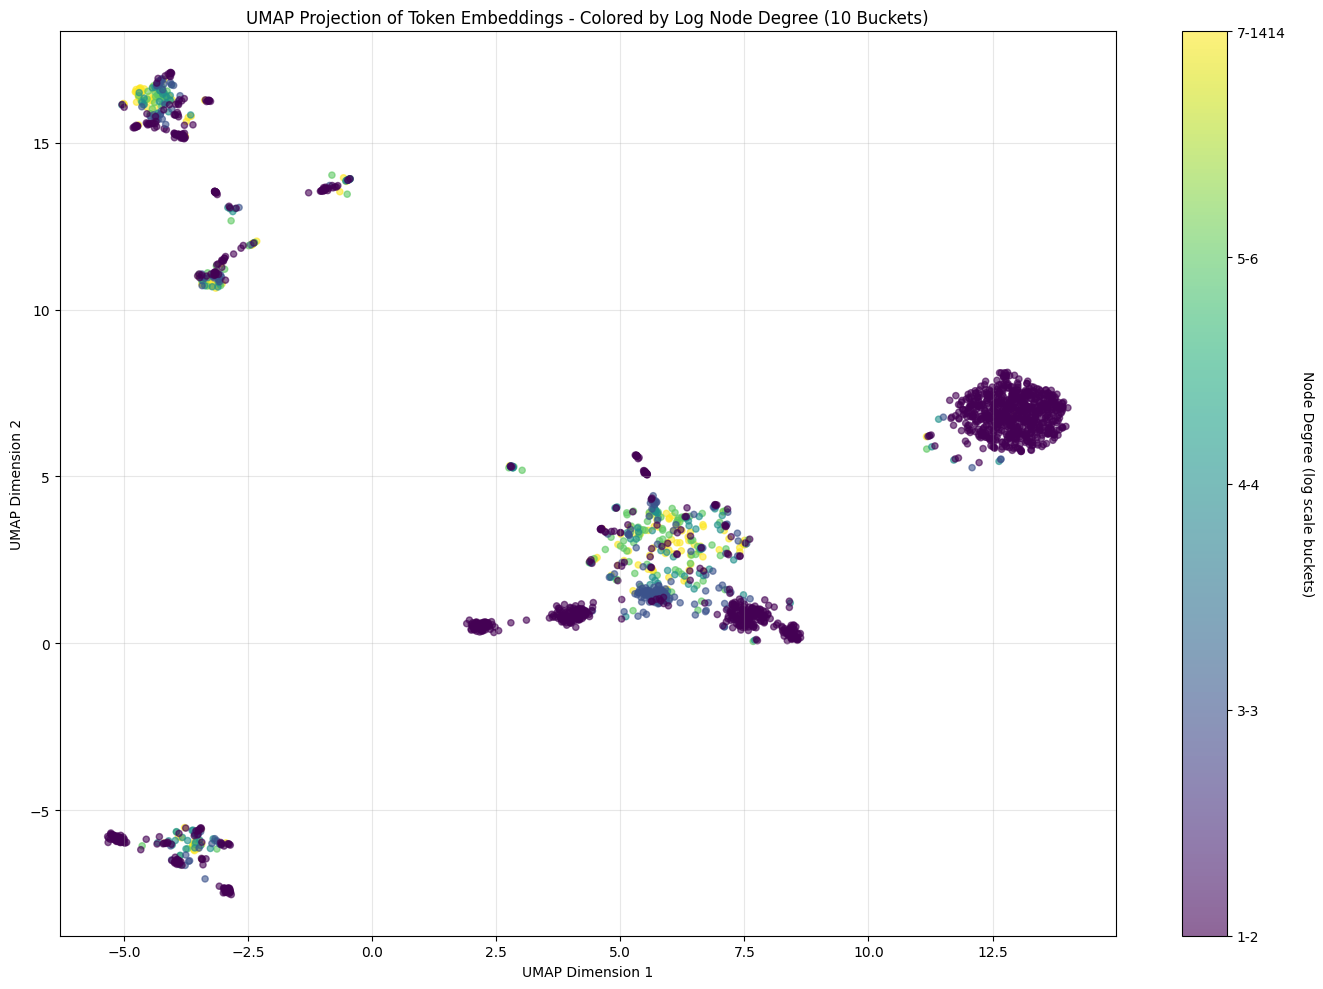


Node Degree Bucket Statistics (log-scale):
Bucket 1: [1, 2] - 1523 tokens
Bucket 2: [3, 3] - 254 tokens
Bucket 3: [4, 4] - 141 tokens
Bucket 4: [5, 6] - 135 tokens
Bucket 5: [7, 1414] - 197 tokens


In [16]:
import pandas as pd

# Create node degree array and apply log transformation
degrees = np.array([G.degree(token) for token in tokens])
log_degrees = np.log1p(degrees)  # log1p = log(1 + x) to handle degree 0 safely

# Create 10 buckets using quantile-based binning on log degrees
log_degree_buckets = pd.qcut(log_degrees, q=10, labels=False, duplicates="drop")

# Get bucket ranges for legend (show original degree ranges)
bucket_info = []
for i in range(int(log_degree_buckets.max()) + 1):
    mask = log_degree_buckets == i
    if mask.any():
        min_deg = degrees[mask].min()
        max_deg = degrees[mask].max()
        bucket_info.append((min_deg, max_deg))

# Plot UMAP projection colored by log node degree buckets
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=log_degree_buckets,
    cmap="viridis",
    alpha=0.6,
    s=20,
)

# Add colorbar with bucket labels showing degree ranges
cbar = plt.colorbar(scatter, ticks=range(len(bucket_info)))
bucket_labels = [f"{int(min_d)}-{int(max_d)}" for min_d, max_d in bucket_info]
cbar.ax.set_yticklabels(bucket_labels)
cbar.set_label("Node Degree (log scale buckets)", rotation=270, labelpad=20)

plt.title(
    "UMAP Projection of Token Embeddings - Colored by Log Node Degree (10 Buckets)"
)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print bucket statistics
print("\nNode Degree Bucket Statistics (log-scale):")
for i, (min_d, max_d) in enumerate(bucket_info):
    count = np.sum(log_degree_buckets == i)
    print(f"Bucket {i + 1}: [{int(min_d)}, {int(max_d)}] - {count} tokens")

In [40]:
# Find tokens with highest degree (most connected)
token_degrees = [(token, G.degree(token)) for token in tokens]
token_degrees_sorted = sorted(token_degrees, key=lambda x: x[1], reverse=True)

print("Top 10 tokens by degree (most connected):\n")
for rank, (token_addr, degree) in enumerate(token_degrees_sorted[:5], 1):
    # Try to find token symbol from pool_to_tokens mapping
    symbol = None
    for pool_addr, pool_info in pool_to_tokens.items():
        if pool_info["token0_address"] == token_addr:
            symbol = pool_info["token0_symbol"]
            break
        elif pool_info["token1_address"] == token_addr:
            symbol = pool_info["token1_symbol"]
            break

    symbol_str = f" ({symbol})" if symbol else ""
    print(f"{rank:2d}. {token_addr}{symbol_str}")
    print(f"    Degree: {degree} (connected to {degree} other tokens)\n")

Top 10 tokens by degree (most connected):

 1. 0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 (weth)
    Degree: 1414 (connected to 1414 other tokens)

 2. 0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 (usdc)
    Degree: 598 (connected to 598 other tokens)

 3. 0xdac17f958d2ee523a2206206994597c13d831ec7 (usdt)
    Degree: 501 (connected to 501 other tokens)

 4. 0x0d500b1d8e8ef31e21c99d1db9a6444d3adf1270 (wmatic)
    Degree: 189 (connected to 189 other tokens)

 5. 0x55d398326f99059ff775485246999027b3197955 (usdt)
    Degree: 166 (connected to 166 other tokens)



In [39]:
# Analyze connected components (islands) in the token graph
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Total connected components: {len(components)}\n")
print("Component sizes:")
for i, size in enumerate(component_sizes, 1):
    print(f"  Component {i}: {size} tokens")
    print(f" Includes USDC_ADDRESS: {USDC_ADDRESS in components[i - 1]}")

print(
    f"\nLargest component: {component_sizes[0]} tokens ({component_sizes[0] / G.number_of_nodes() * 100:.1f}% of total)"
)


Total connected components: 4

Component sizes:
  Component 1: 2231 tokens
 Includes USDC_ADDRESS: False
  Component 2: 15 tokens
 Includes USDC_ADDRESS: True
  Component 3: 2 tokens
 Includes USDC_ADDRESS: False
  Component 4: 2 tokens
 Includes USDC_ADDRESS: False

Largest component: 2231 tokens (99.2% of total)
